In [2]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd
import os 


23/03/26 - 21:40:21 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
23/03/26 - 21:40:21 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 81): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


23/03/26 - 21:40:22 - pyGIMLi - INFO - Data error estimate (min:max)  0.05000646492989695 : 0.05498040002706264
23/03/26 - 21:40:22 - pyGIMLi - INFO - 0.662636985614011 1229.5566691596337
23/03/26 - 21:40:22 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
23/03/26 - 21:40:22 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
23/03/26 - 21:40:22 - pyGIMLi - INFO - Sim rhoa (min/max) :  57.690391453248104 140.35602680087445
23/03/26 - 21:40:22 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.000646492989695 5.498040002706264
23/03/26 - 21:40:22 - pyGIMLi - INFO - filtered rhoa minmax dd :  57.690391453248104 140.35602680087445


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


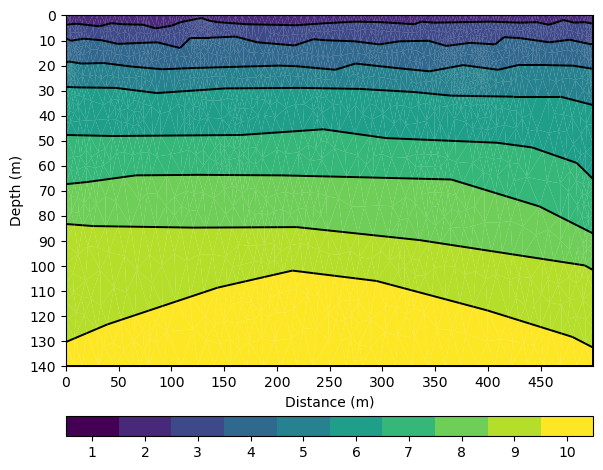

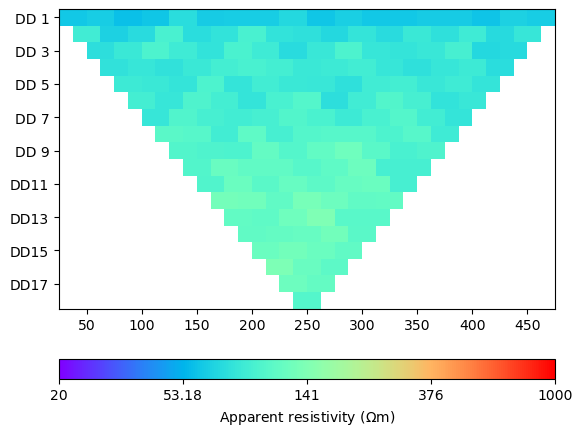

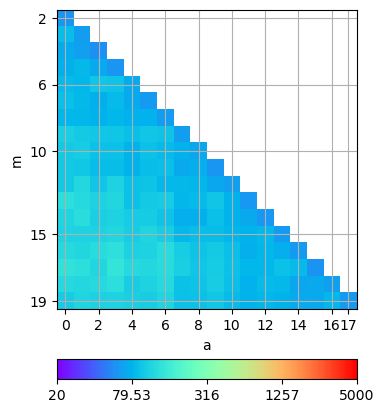

In [3]:
output_dir = "test_change"
os.makedirs(output_dir, exist_ok=True)

world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)
poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)


interfaces = []



for i in range(9):

    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")

#plt.draw()


spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity for each region
#pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=5, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

os.makedirs(output_dir, exist_ok=True) #Make new dir to save files

data.save(os.path.join(output_dir, f'{output_dir}_dd.dat'))

ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=5000,logScale=True,title='DD')

np.save(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy')) 

In [23]:
def fill_nan(image):
    image=image.copy()
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value
    return image, nan_mask


def compress(image, n_singular_values, n_pixels, z_factor): 
    image, nan_mask = fill_nan(image)
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    U_reduced = U[:,:n_singular_values]
    S_reduced = np.diag(S[:n_singular_values])
    Vt_reduced = Vt[:n_singular_values,:]
    compressed_image = np.dot(U_reduced, np.dot(S_reduced, Vt_reduced))    
    contributions = np.abs(U_reduced) @ np.abs(Vt_reduced)
    
    # Apply depth weighting to contributions
    rows, cols = np.arange(image.shape[0]), np.arange(image.shape[1])
    z = rows / np.max(rows)
    depth_weight = 1 + z_factor * z   
    depth_weight = depth_weight[:, None]
    contributions *= depth_weight

    contributions[nan_mask] = -np.inf

    #anchor points
    #first column (idx= 0)
    valid_rows_0 = np.flatnonzero(~nan_mask[:, 0])
    
    if valid_rows_0.size > 0:
        rows_min, rows_max, rows_mean = valid_rows_0[0], valid_rows_0[-1],valid_rows_0[valid_rows_0.size // 2]
        contributions[rows_min, 0],contributions[rows_max, 0], contributions[rows_mean, 0] = np.inf, np.inf, np.inf

    flat_indices = np.argsort(contributions.flatten())[::-1][:n_pixels]
    significant_indices = np.unravel_index(flat_indices, image.shape)

    return compressed_image, significant_indices, nan_mask, contributions


def reconstruct(image_shape, significant_indices, pixel_values):
    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)
    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values
    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image
def plot_ert_checkerboard(data,plot=0):
    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)
    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']
    if plot==1:
        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')
        plt.show()
    return heatmap

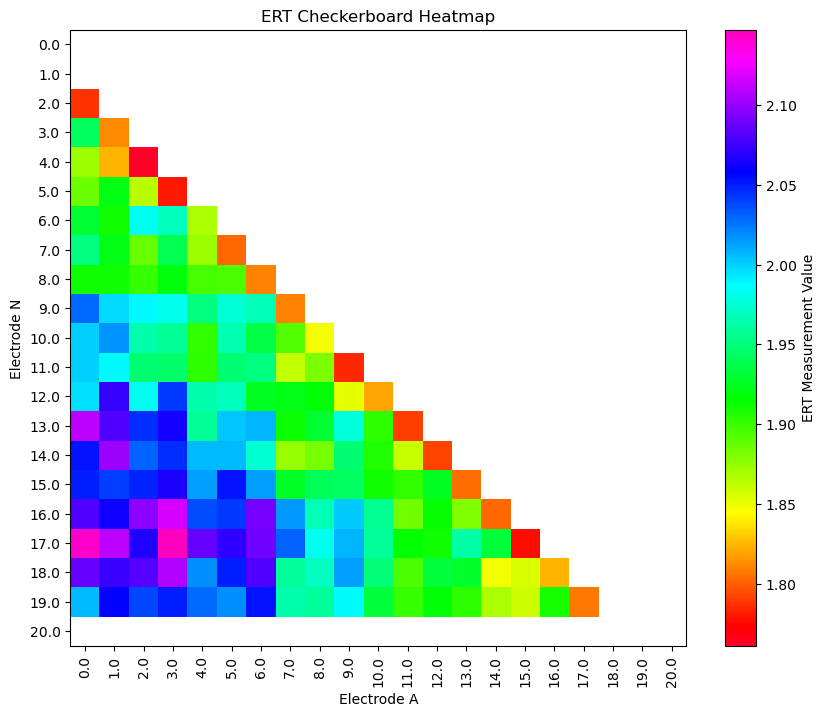

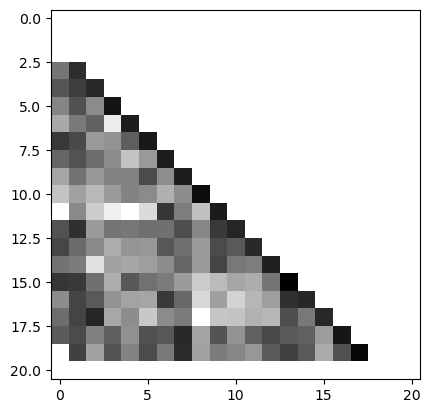

In [18]:
abmn_data=np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'))
data_all=np.column_stack((abmn_data, res_data))
data=pd.DataFrame(data_all, columns=['A', 'B', 'M', 'N', 'Res'])
image=plot_ert_checkerboard(data,plot=1)

n_singular_values=21
n_pixels=image[~np.isnan(image)].size
z_factor=0

compressed_image, significant_indices, nan_mask, contributions = compress(image, n_singular_values, n_pixels, z_factor)
pixel_values = compressed_image[significant_indices]
real_values = image[significant_indices]
reconstructed_image = reconstruct(image.shape, significant_indices, pixel_values)
predicted_values = reconstructed_image[significant_indices]

plt.imshow(contributions, cmap='binary')

Significant pixel indices (2D): (array([ 2, 11, 19, 15, 19, 10,  5, 18,  7, 11,  8,  6,  9, 14, 17, 12, 16,
        4, 18, 17, 13, 19,  3, 16, 12, 15, 11,  7, 12, 16, 15,  4, 19, 19,
       17, 16, 14, 13, 18,  7, 13,  9, 19, 18, 17, 12, 19,  5, 18,  8, 12,
       18, 19,  4, 13, 18, 15, 13, 19, 16, 18, 18, 19,  7, 18,  6, 18, 18,
        8, 14, 16, 13,  8, 17, 13, 12, 15, 12, 15,  9, 14, 12, 15,  3, 12,
       17, 14,  6, 19, 15, 14, 17, 19, 14, 11, 18,  9, 10, 19,  9,  5, 19,
       12, 13, 11,  5, 17, 10,  8, 16, 17, 10, 14,  9, 18, 18, 16,  7, 13,
       13, 19,  9,  8, 13, 14,  7, 15, 10, 12, 18, 14, 16, 16, 19, 19, 14,
       10, 16, 18, 16, 15,  9, 14, 17,  6, 19, 15, 13, 15, 10, 17, 16, 17,
       10, 15, 11, 10,  8, 17, 17, 17, 15, 11, 16, 16, 11, 14,  6, 11, 17,
       11], dtype=int64), array([ 0,  0,  0, 13, 17,  8,  3, 16,  5,  9,  6,  4,  7, 12,  2, 10, 14,
        2,  7, 15, 11,  7,  1, 13,  1,  0,  6,  0,  9,  6,  1,  1, 13,  1,
        1,  1,  9,  0, 12,  1,  9,  5,  5

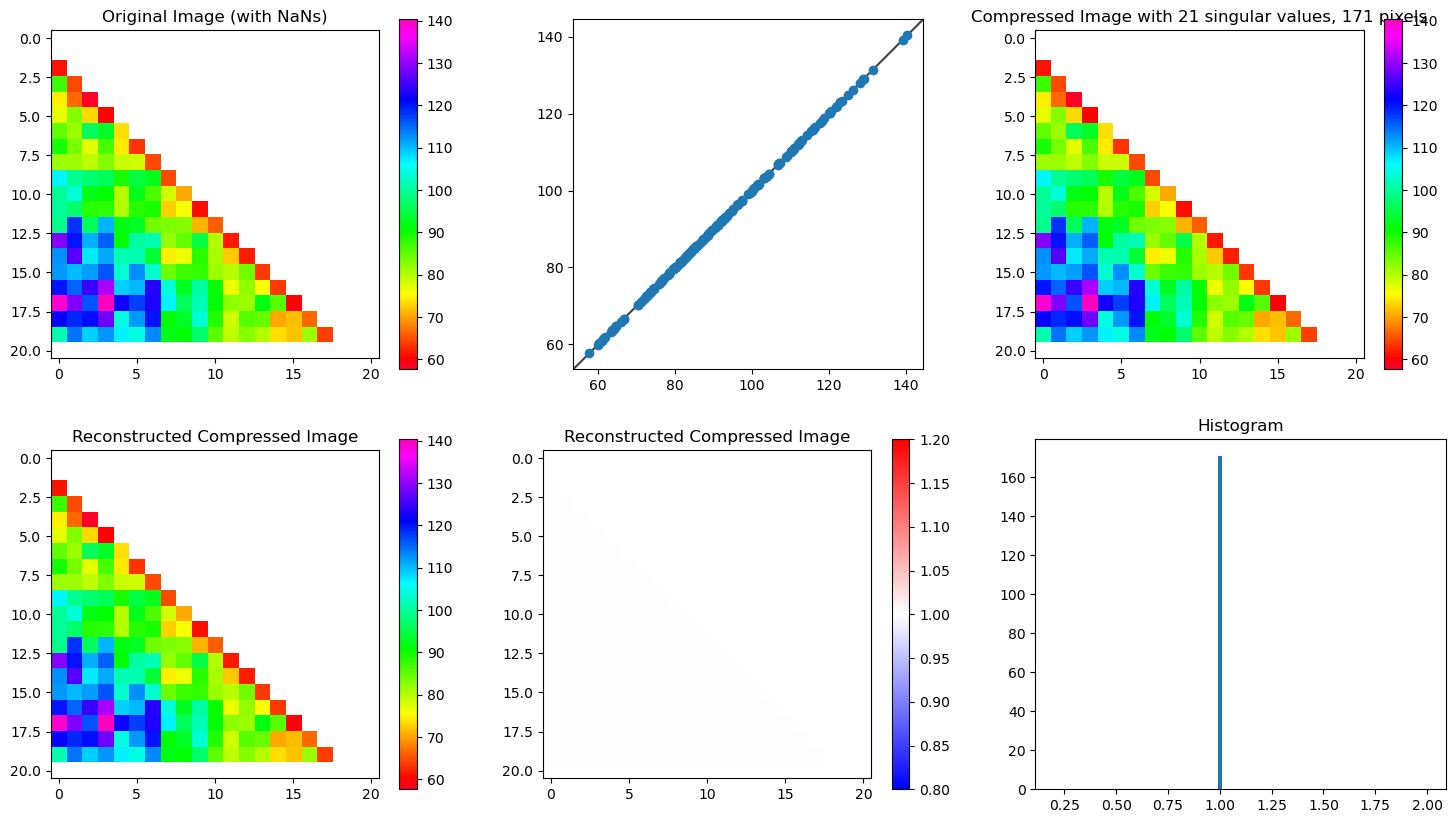

In [19]:





fig , ( (ax1,ax2,ax5) , (ax3,ax4,ax6)) = plt.subplots(2,3, figsize=(18,10))

#Plot 1: Original Image  
ax1.set_title("Original Image (with NaNs)")
im1=ax1.imshow(image, cmap='gist_rainbow')
plt.colorbar(im1)

#Plot 2: Scatter Plot
ax2.scatter(image.ravel(),reconstructed_image.ravel())

lims = [
np.min([ax2.get_xlim(), ax2.get_ylim()]),  # min of both axes
np.max([ax2.get_xlim(), ax2.get_ylim()]),  # max of both axes
]

ax2.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax2.set_aspect('equal')
ax2.set_xlim(lims)
ax2.set_ylim(lims)

#Plot 3: Reconstructed Image
ax3.set_title("Reconstructed Compressed Image")
reconstructed_image[nan_mask] = np.nan
im3=ax3.imshow(reconstructed_image, cmap='gist_rainbow')
plt.colorbar(im3)

#Plot 4: Ratio Image
ax4.set_title("Reconstructed Compressed Image")
im4=ax4.imshow(image/reconstructed_image, cmap='bwr',vmin=0.8,vmax=1.2)
plt.colorbar(im4)

#Plot 5: Compressed Image
del1=np.asarray(significant_indices)
to_plot_image=np.copy(image)
to_plot_image[:]=np.nan
to_plot_image[del1[0,:].T,del1[1,:].T]=predicted_values

ax5.set_title(f"Compressed Image with {n_singular_values} singular values, {n_pixels} pixels")
compressed_image[nan_mask] = np.nan
im5=ax5.imshow(to_plot_image, cmap='gist_rainbow')
plt.colorbar(im5)

#Plot 6: Histogram
ax6.set_title("Histogram")
ax6.hist(image.ravel()/reconstructed_image.ravel(),bins=100,range=(0.2,2))

print("Significant pixel indices (2D):", significant_indices)
print("Pixel values at significant indices:", pixel_values)
print(np.count_nonzero(np.isfinite(image.ravel())))
print(np.count_nonzero(np.isfinite(pixel_values)))

electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}

new_rhoa = []
for _, row in data.iterrows():
    x=electrode_map[row['A']]
    y=electrode_map[row['M']]
    
    
    val=reconstructed_image[y, x]
    new_rhoa.append(val)

new_rhoa=np.array(new_rhoa)
np.save('res_t_dd_reconstructed.npy', new_rhoa)


In [33]:
n_pixels_max=image[~np.isnan(image)].size
k=21
results = []
for i in range(1,k+1):
    for j in range(n_pixels_max, 10, -10):
        compressed_image, significant_indices, nan_mask, contributions = compress(image, i, j, z_factor)
        pixel_values = compressed_image[significant_indices]
        reconstructed_image = reconstruct(image.shape, significant_indices, pixel_values)
        predicted_values = reconstructed_image[significant_indices]
        valid_mask = ~np.isnan(image)
        rmse=np.sqrt(np.nanmean((image[valid_mask] - reconstructed_image[valid_mask]) ** 2))
        print(f"Singular Values: {i}, Pixels: {j}, RMSE: {rmse}")
        results.append(({ 'singular_values': i, 'pixels': j, 'rmse': rmse }))   #dictionary

rmse_df = pd.DataFrame(results)


for n in range(1,k+1):
    df_k{n} = rmse_df[rmse_df['singular_values'] == n].sort_values(by='pixels', ascending=False)
    plt.figure(figsize=(8, 5))
    plt.plot(df_k{n}['pixels'], df_k{n}['rmse'], marker='o', color='b')
    plt.gca().invert_xaxis()
    plt.xlabel("Number of Pixels")
    plt.ylabel("RMSE")
    plt.title(f"RMSE vs Decreasing Pixels (Rank k={n})")
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'rmse_k_{n}.png'))
    plt.close()






SyntaxError: invalid syntax (3781247287.py, line 19)